In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import urllib.request
from io import BytesIO

In [ ]:
def compress_channel(U, S, Vt, k):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    return np.dot(U_k, np.dot(S_k, Vt_k))

In [ ]:
def calc_relative_error(Y_original, Y_compressed):
    numerator = np.linalg.norm(Y_original - Y_compressed, 'fro')
    denominator = np.linalg.norm(Y_original, 'fro')
    return numerator / denominator

In [ ]:
def get_placeholder_image(color=False):
    x, y = np.meshgrid(np.linspace(-4, 4, 256), np.linspace(-4, 4, 256))
    base = np.sin(x**2 + y**2) * 127 + 128
    if not color:
        return np.clip(base, 0, 255)
    else:
        img = np.zeros((256, 256, 3))
        img[:,:,0] = np.clip(base + x*20, 0, 255)
        img[:,:,1] = np.clip(base - y*20, 0, 255)
        img[:,:,2] = np.clip(base + 50, 0, 255)
        return img


def get_luminance(R, G, B):
    return 0.299 * R + 0.587 * G + 0.114 * B

In [ ]:
img_gray = get_placeholder_image(color=False)
img_color = get_placeholder_image(color=True)

import matplotlib.image as mpimg
img_color = mpimg.imread('image.jpg')
img_gray = np.mean(img_color, axis=2)

k_values_to_show = [1, 2, 5, 20, 50, 100, 194]
k_values_for_plot = list(range(1, 150, 5))

In [ ]:
def svd(A):
    U, S, V = np.linalg.svd(A)
    X = np.zeros((U.shape[1], V.shape[0]))
    X[np.diag_indices(min(U.shape[1], V.shape[0]))] = S
    return U, S, V

Сжатие ЧБ изображения для разных k...


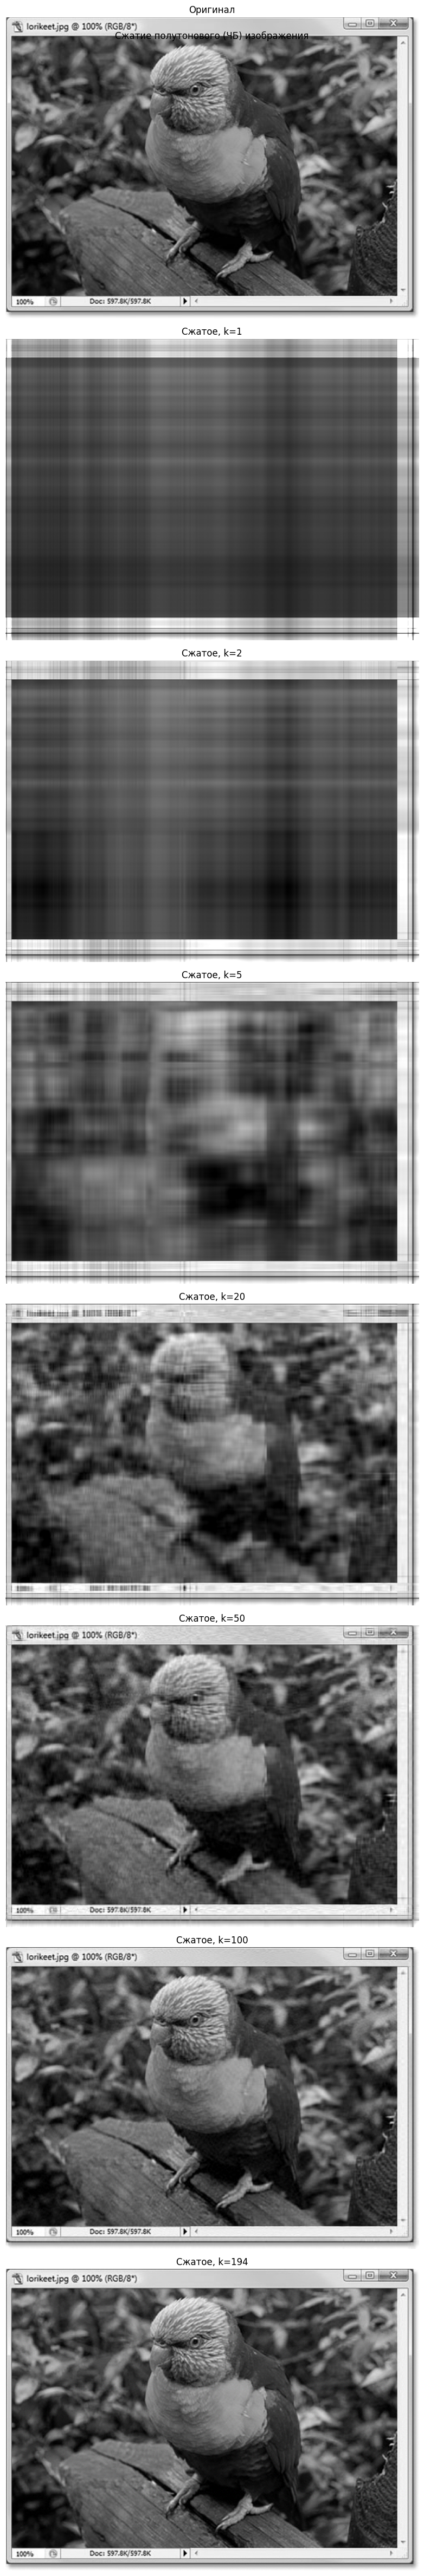

In [ ]:
U_g, S_g, Vt_g = svd(img_gray)

num_plots = len(k_values_to_show) + 1
fig, axes = plt.subplots(num_plots, 1, figsize=(8, 6 * num_plots))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Оригинал")
axes[0].axis('off')

errors_gray = []

print("Сжатие ЧБ изображения для разных k...")
for idx, k in enumerate(k_values_to_show):
    compressed_gray = compress_channel(U_g, S_g, Vt_g, k)
    compressed_gray = np.clip(compressed_gray, 0, 255)

    axes[idx+1].imshow(compressed_gray, cmap='gray')
    axes[idx+1].set_title(f"Сжатое, k={k}")
    axes[idx+1].axis('off')

for k in k_values_for_plot:
    comp_g = compress_channel(U_g, S_g, Vt_g, k)
    errors_gray.append(calc_relative_error(img_gray, comp_g))

plt.suptitle("Сжатие полутонового (ЧБ) изображения")
plt.tight_layout()
plt.show()

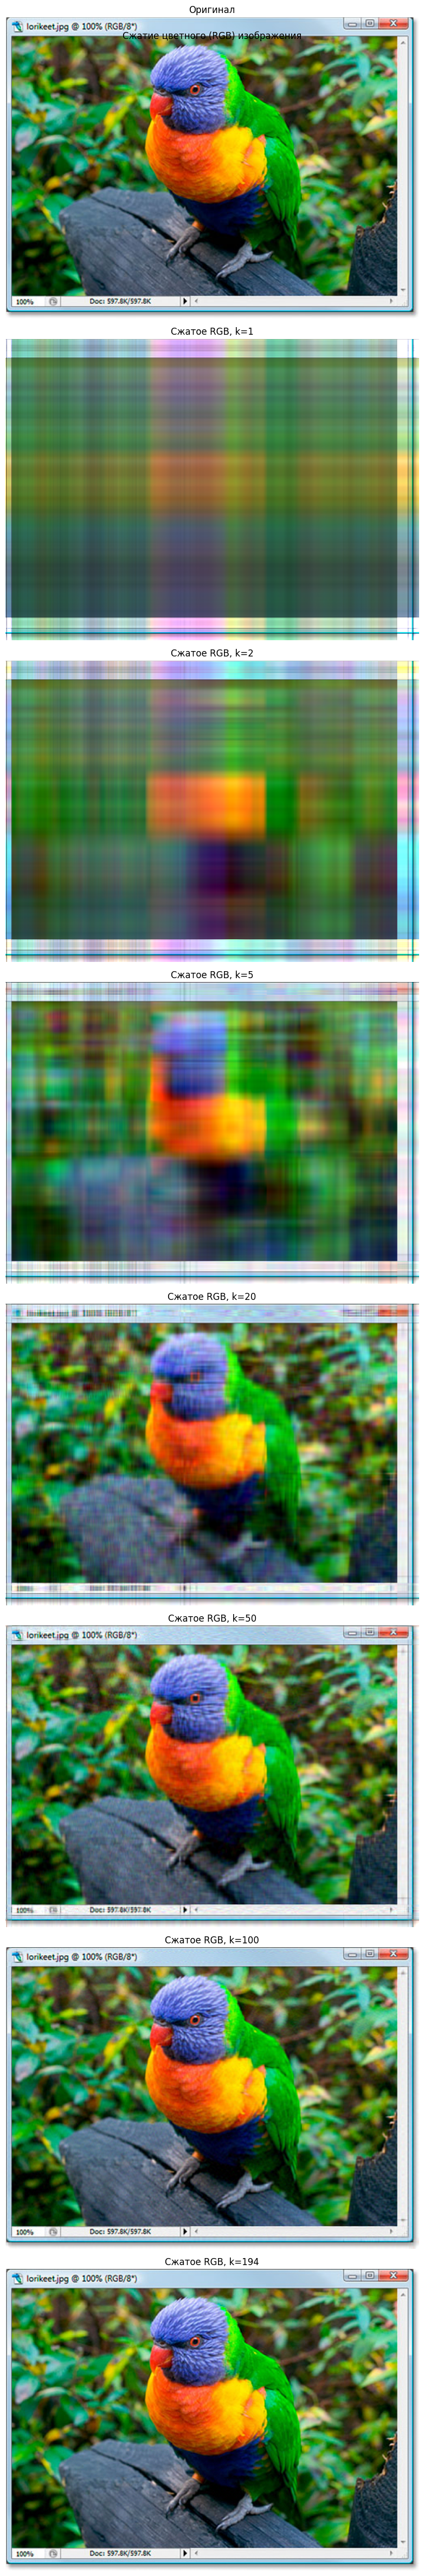

In [ ]:
R, G, B = img_color[:,:,0], img_color[:,:,1], img_color[:,:,2]

U_R, S_R, Vt_R = svd(R)
U_G, S_G, Vt_G = svd(G)
U_B, S_B, Vt_B = svd(B)

num_plots = len(k_values_to_show) + 1
fig_c, axes_c = plt.subplots(num_plots, 1, figsize=(8, 6 * num_plots))
axes_c[0].imshow(img_color.astype(np.uint8))
axes_c[0].set_title("Оригинал")
axes_c[0].axis('off')

errors_color = []

Y_orig = get_luminance(R, G, B)

for idx, k in enumerate(k_values_to_show):
    comp_R = compress_channel(U_R, S_R, Vt_R, k)
    comp_G = compress_channel(U_G, S_G, Vt_G, k)
    comp_B = compress_channel(U_B, S_B, Vt_B, k)

    comp_color = np.stack((comp_R, comp_G, comp_B), axis=2)
    comp_color = np.clip(comp_color, 0, 255)

    axes_c[idx+1].imshow(comp_color.astype(np.uint8))
    axes_c[idx+1].set_title(f"Сжатое RGB, k={k}")
    axes_c[idx+1].axis('off')

for k in k_values_for_plot:
    comp_R = compress_channel(U_R, S_R, Vt_R, k)
    comp_G = compress_channel(U_G, S_G, Vt_G, k)
    comp_B = compress_channel(U_B, S_B, Vt_B, k)

    Y_comp = get_luminance(comp_R, comp_G, comp_B)
    errors_color.append(calc_relative_error(Y_orig, Y_comp))

plt.suptitle("Сжатие цветного (RGB) изображения")
plt.tight_layout()
plt.show()



--- Задание C: Графики погрешности ---


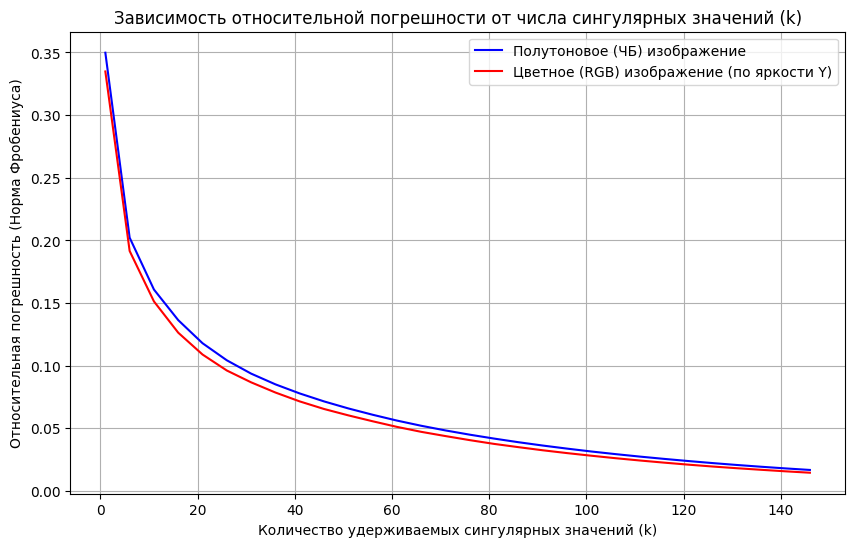

In [ ]:
print("\n--- Задание C: Графики погрешности ---")
plt.figure(figsize=(10, 6))
plt.plot(k_values_for_plot, errors_gray, 'b-', label='Полутоновое (ЧБ) изображение')
plt.plot(k_values_for_plot, errors_color, 'r-', label='Цветное (RGB) изображение (по яркости Y)')

plt.title('Зависимость относительной погрешности от числа сингулярных значений (k)')
plt.xlabel('Количество удерживаемых сингулярных значений (k)')
plt.ylabel('Относительная погрешность (Норма Фробениуса)')
plt.grid(True)
plt.legend()
plt.show()